# **Proyecto 08: Sistema de Identificación de Especies de Aves con Imágenes y Deep Learning**

---
## **Parte 1: Carga del data set**



Empezaremos cargando las imágenes de aves que formarán el dataset. Hay que tener en cuenta que las imágenes pueden tener tamaños distintos, así que vamos a fijar que todas ellas se deben convertir en imágenes de 256x256 píxeles y 3 canales.

In [1]:
# Definimos las dimensiones de las imágenes
IMG_ROWS = 256
IMG_COLS = 256
CHANNELS = 3
IMG_SHAPE = (IMG_ROWS, IMG_COLS, CHANNELS)

print(f"Las imágenes se redimensionarán a: {IMG_SHAPE}")

Las imágenes se redimensionarán a: (256, 256, 3)


Para cargar y procesar las imágenes de forma mucho más rápida y eficiente, hemos sustituido el antiguo `ImageDataGenerator` por la API moderna de **TensorFlow**: [**image_dataset_from_directory**](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory) en conjunto con la API **tf.data**. Este nuevo bloque realiza varias mejoras:

*   **Carga inicial**: Divide el dataset original en un conjunto de entrenamiento (80%) y otro de validación (20%), utilizando modo categórico y procesando todo en lotes.
*   **Data Augmentation Directo**: Aplicamos directamente sobre tensores las transformaciones de aumentar datos (voltear horizontalmente gracias a `RandomFlip` y rotar la imagen con `RandomRotation`).
*   **Optimización Multihilo**: Al emplear `tf.data.AUTOTUNE` dentro de las funciones `.map()` y `.prefetch()`, el procesador se encarga automáticamente de decidir cuántos hilos utilizar para cargar anticipadamente a memoria y pre-procesar porciones de las imágenes sin detener el entrenamiento en la GPU. Todo esto disminuye dramáticamente el tiempo de ejecución en cada *step*.

Inicialmente estabamos entorno a los 500ms/step, y con estos cambios hemos conseguido reducirlo a 50ms/step, una mejora sustancial que nos ha permitido probar distintas configuraciones en menor tiempo.

In [2]:
from tensorflow.keras import mixed_precision

# Activamos precisión mixta global
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

I0000 00:00:1778947213.161963   66961 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
import tensorflow as tf

# Directorio base donde están las carpetas de las clases de aves
data_dir = 'CUB_200_2011/images'

# Al usar la API tf.data moderna es más rápido
batch_size = 32 # Puedes subirlo si tu GPU lo soporta
AUTOTUNE = tf.data.AUTOTUNE

# 1. Cargamos las imágenes de entrenamiento (80%)
raw_train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=121,
    image_size=(IMG_ROWS, IMG_COLS),
    batch_size=batch_size,
    label_mode='categorical'
)

# 2. Cargamos las imágenes de validación (20%)
raw_validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=121,
    image_size=(IMG_ROWS, IMG_COLS),
    batch_size=batch_size,
    label_mode='categorical'
)

# Obtenemos el número de clases
num_classes = len(raw_train_dataset.class_names)

# Tareas de aumento de datos
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.125), # equivale a 45 grados (1 = 360)
])

# Funciones de map para transformar datos usando la CPU eficientemente
def prepare_train(image, label):
    image = image / 255.0 # rescale
    image = data_augmentation(image, training=True)
    return image, label

def prepare_val(image, label):
    image = image / 255.0 # rescale
    return image, label

# 3. Optimización con tf.data
train_dataset = (
    raw_train_dataset
    .map(prepare_train, num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

validation_dataset = (
    raw_validation_dataset
    .map(prepare_val, num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

print(f"Número de clases: {num_classes}")

Found 11788 files belonging to 200 classes.
Using 9431 files for training.


I0000 00:00:1778947216.896455   66961 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5590 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:26:00.0, compute capability: 8.6


Found 11788 files belonging to 200 classes.
Using 2357 files for validation.
Número de clases: 200


---

## **Parte 2: Análisis del model (Entrenamiento de la red neuronal)**

Para el modelo de la CNN (red neuronal convolucional), vamos a importar los siguientes objetos de la librería <span style="color:blue"> **keras**</span>: [**Sequential**](https://keras.io/api/models/sequential/), [**load_model**](https://keras.io/api/models/model_saving_apis/model_saving_and_loading/) [**Dense**](https://keras.io/api/layers/core_layers/dense/), [**Dropout**](https://keras.io/api/layers/regularization_layers/dropout/), [**Dropout**](https://keras.io/api/layers/regularization_layers/dropout/), [**Flatten**](https://keras.io/api/layers/reshaping_layers/flatten/), [**Conv2D**](https://keras.io/api/layers/convolution_layers/convolution2d/) y [**MaxPooling2D**](https://keras.io/api/layers/pooling_layers/max_pooling2d/).

Crearemos una red neuronal (se empieza con la función Sequential, y luego se van añadiendo capas con add) con las siguientes capas:

- Convolucional: 64 neuronas, kernel de 3x3, tamaño de entrada de filas de la imagen, columnas de la imagen y canales.
- Activación: 'relu'
- Convolucional: 64 neuronas, kernel de 3x3
- Activación: 'relu'
- Pooling: tamaño 4x4
- Convolucional: 64 neuronas, kernel de 3x3
- Activación: 'relu'
- Convolucional: 64 neuronas, kernel de 3x3
- Activación: 'relu'
- Pooling: tamaño 4x4
- Flatten
- Dropout: 0.5
- Capa densa: 400 neuronas
- Activación: 'relu'
- Dropout: 0.5
- Capa densa: 200 neuronas
- Activación: 'softmax'

Depués de crear la arquitectura de la red, la compilamos con la función <span style="color:blue"> **compile**</span>. Utilizamos los siguientes hiperparámetros: (pérdidas: 'categorical_crossentropy', optimizador: 'adamax', métrica de desempeño: 'accuracy'). Podemos ver a continuación un resumen de la arquitectura creada con la instrucción <span style="color:blue"> **summary**</span>.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation

# num_classes ya fue definido en la celda anterior al cargar el dataset

model = Sequential()

# 1. Convolucional: 64 neuronas, kernel 3x3 + Relu
model.add(Conv2D(64, (3, 3), input_shape=IMG_SHAPE))
model.add(Activation('relu'))

# 2. Convolucional: 64 neuronas, kernel 3x3 + Relu
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))

# 3. Pooling: tamaño 4x4
model.add(MaxPooling2D(pool_size=(4, 4)))

# 4. Convolucional: 64 neuronas, kernel 3x3 + Relu
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))

# 5. Convolucional: 64 neuronas, kernel 3x3 + Relu
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))

# 6. Pooling: tamaño 4x4
model.add(MaxPooling2D(pool_size=(4, 4)))

# 7. Flatten
model.add(Flatten())

# 8. Dropout: 0.5
model.add(Dropout(0.5))

# 9. Capa densa: 400 neuronas + Relu
model.add(Dense(400))
model.add(Activation('relu'))

# 10. Dropout: 0.5
model.add(Dropout(0.5))

# 11. Capa densa: 200 neuronas (ajustado al num_classes si es la salida) + Softmax
model.add(Dense(num_classes))
model.add(Activation('softmax'))

# Compilación
model.compile(loss='categorical_crossentropy',
              optimizer='adamax',
              metrics=['accuracy'])

# Resumen del modelo
model.summary()

/home/jose/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 254, 254, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 252, 252, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 252, 252, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 59, 59, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 400)            │     5,018,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 200)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,210,776 (19.88 MB)

 Trainable params: 5,210,776 (19.88 MB)

 Non-trainable params: 0 (0.00 B)

Podemos visualizar el desempeño de nuestra red a lo largo de las fases de entrenamiento. Para ello, utilizaremos TensorBoard. Salvaremos todos los resultados de entrenamiento en un directorio llamado <span style="color:red"> custom</span>. Descomentad las dos lineas siguientes de código para crear el tensorboard.

In [5]:
from tensorflow.keras.callbacks import TensorBoard

# Creamos el callback para visualizar en TensorBoard
tensorboard = TensorBoard(log_dir='./logs/custom2')

Entrenaremos utilizando la función <span style="color:blue"> **fit**</span>, donde suministramos directamente nuestros objetos de datos `train_dataset` y `validation_dataset` que son hiperrápidos gracias a **tf.data**. Utilizaremos hiperparámetros como: épocas = 30 y callbacks=[tensorboard] (nótese que al usar datasets modernos ya no es necesario especificar *steps_per_epoch*, TensorFlow lo calcula automáticamente en función del tamaño del batch y del dataset completo). Por último, también podemos evaluar los resultados de nuestro modelo mediante la función <span style="color:blue"> **evaluate**</span>, pasándole los datos de validación y obteniendo unos datos de desempeño sobre los aciertos y errores del modelo.

In [6]:
# 1. Entrenamiento del modelo
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[tensorboard]
)

# 2. Evaluación final del modelo
loss, accuracy = model.evaluate(validation_dataset)

print(f"\nResultados en el set de validación:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

Epoch 1/30


I0000 00:00:1778947221.498623   67053 service.cc:153] XLA service 0x7f08fc036840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778947221.498673   67053 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778947221.614162   67053 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778947221.829124   67053 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778947221.888011   67053 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3145__.54
I0000 00:00:1778947243.072105   67053 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


  1/295 ━━━━━━━━━━━━━━━━━━━━ 2:49:25 35s/step - accuracy: 0.0000e+00 - loss: 5.2981

I0000 00:00:1778947254.258703   67053 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0038 - loss: 5.3025

I0000 00:00:1778947268.780613   67052 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3145__.54


295/295 ━━━━━━━━━━━━━━━━━━━━ 79s 152ms/step - accuracy: 0.0039 - loss: 5.2999 - val_accuracy: 0.0042 - val_loss: 5.2990
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.0067 - loss: 5.2822 - val_accuracy: 0.0106 - val_loss: 5.2267
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.0133 - loss: 5.1745 - val_accuracy: 0.0148 - val_loss: 5.0655
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.0208 - loss: 5.0208 - val_accuracy: 0.0297 - val_loss: 4.8607
Epoch 5/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.0265 - loss: 4.8902 - val_accuracy: 0.0365 - val_loss: 4.7419
Epoch 6/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.0324 - loss: 4.7770 - val_accuracy: 0.0458 - val_loss: 4.6010
Epoch 7/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.0426 - loss: 4.6608 - val_accuracy: 0.0602 - val_loss: 4.4455
Epoch 8/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.0534 - loss: 4.5311 - val_accura

In [7]:
model.save("birds.keras")

# Reentrenamiento con Early Stopping

A continuación vamos a reentrenar y refinar nuestro modelo añadiendo un callback muy útil llamado **Early Stopping** (Parada Temprana). 
Lo que hace este callback es monitorizar una métrica en particular (en este caso, la pérdida en el conjunto de validación `val_loss`). Le hemos asignado un parámetro de paciencia (`patience=5`), lo cual significa que si la red entrena durante 5 épocas seguidas y no observa ninguna mejora en esa pérdida de validación, detendrá automáticamente el entrenamiento. Posteriormente, restaurará los mejores pesos encontrados (`restore_best_weights=True`) previos a que el modelo empezara a degradarse o a sobreajustarse al entrenamiento (overfitting). Gracias a esta técnica y a la alta velocidad que hemos conseguido con `tf.data`, podemos permitirnos subir el número de épocas a 50 sin preocuparnos de gastar tiempo excesivo si el modelo llega a su cima de aprendizaje mucho antes de acabar.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Definir el callback de Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reentrenamiento del modelo con Early Stopping
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=[tensorboard, early_stopping]
)

# Evaluación final después del reentrenamiento
loss, accuracy = model.evaluate(validation_dataset)

print(f"\nResultados después del reentrenamiento:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

Epoch 1/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.2849 - loss: 2.9127 - val_accuracy: 0.2444 - val_loss: 3.1749
Epoch 2/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.2919 - loss: 2.8587 - val_accuracy: 0.2452 - val_loss: 3.1555
Epoch 3/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.3023 - loss: 2.8339 - val_accuracy: 0.2567 - val_loss: 3.1031
Epoch 4/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.3110 - loss: 2.7708 - val_accuracy: 0.2584 - val_loss: 3.1053
Epoch 5/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.3143 - loss: 2.7639 - val_accuracy: 0.2580 - val_loss: 3.0972
Epoch 6/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.3241 - loss: 2.7207 - val_accuracy: 0.2647 - val_loss: 3.0919
Epoch 7/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.3284 - loss: 2.6723 - val_accuracy: 0.2686 - val_loss: 3.0743
Epoch 8/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.3385 - loss: 2.6466 - 

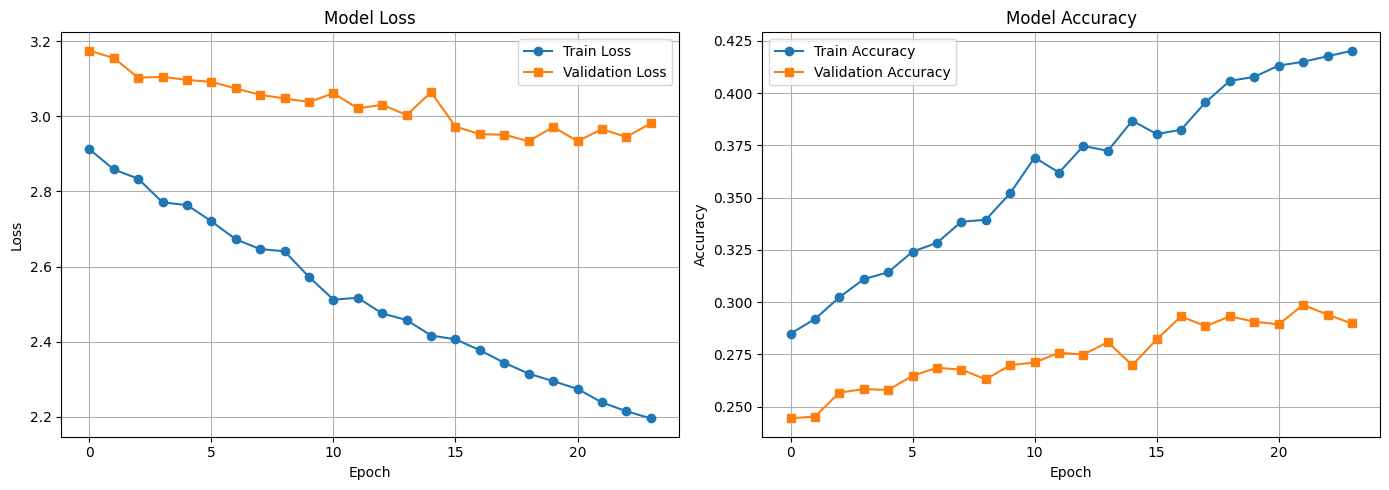

In [9]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Crear figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
ax1.plot(train_loss, label='Train Loss', marker='o')
ax1.plot(val_loss, label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Model Loss')
ax1.legend()
ax1.grid(True)

# Gráfico de precisión
ax2.plot(train_accuracy, label='Train Accuracy', marker='o')
ax2.plot(val_accuracy, label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Podemos observar que la precision de entrenamiento vs la validación, se separan mucho apartir de 10 epochs y no conseguimos realmente superar el umbral del 30% por lo que no tiene sentido seguir haciendo mas epochs con el tipo de modelo que tenemos actualmente

In [ ]:
#Finalmente guardamos el modelo entrenado
model.save("birds_final.keras")